In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Set data type for TensorFlow
DTYPE = 'float32'
tf.keras.backend.set_floatx(DTYPE)

print("TensorFlow version:", tf.__version__)
# Financial parameters for the European put option
K = 100.0       # Strike price
r = 0.05        # Risk-free interest rate
sigma = 0.20    # Volatility
T = 1.0         # Time to maturity (in years)

# Fractional parameter
alpha = 0.8    

# Domain boundaries
S_min = 0.0
S_max = 200.0
t_min = 0.0
t_max = T

TensorFlow version: 2.19.0


In [2]:
def build_model(num_hidden_layers=4, num_neurons=20):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.InputLayer(input_shape=(2,)))
    for _ in range(num_hidden_layers):
        model.add(tf.keras.layers.Dense(num_neurons, activation='tanh',
                                        kernel_initializer='glorot_normal'))
    model.add(tf.keras.layers.Dense(1))
    return model

pinn_model = build_model()
pinn_model.summary()

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 20)                  │              60 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 20)                  │             420 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 20)                  │             420 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 20)                  │             420 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              21 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,341 (5.24 KB)

 Trainable params: 1,341 (5.24 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
def _caputo_scalar(args):
    model, t, S, alpha, n_steps = args
    if t == 0.0:
        return tf.constant(0.0, dtype=DTYPE)

    # Pre-calculate the Gamma function term
    gamma_val = tf.exp(tf.math.lgamma(1.0 - alpha))
    
    # Create the time steps for the Riemann sum integral approximation
    tau = tf.linspace(0.0, t, n_steps + 1)
    dt = tau[1] - tau[0]

    # Calculate the first derivative dV/d_tau, which is inside the integral
    with tf.GradientTape() as tape:
        tape.watch(tau)
        # Use tf.fill to create a tensor of S with the same shape as tau
        S_rep = tf.fill(tau.shape, S)
        # Predict V at each time step tau
        V_tau = model(tf.stack([tau, S_rep], axis=1))

    dV_dtau = tape.gradient(V_tau, tau)
    
    # If the gradient is None (can happen in edge cases like t=0), return 0
    if dV_dtau is None:
        return tf.constant(0.0, dtype=DTYPE)
    
    # Approximate the integral using a Riemann sum, as per the paper's method
    integrand = (t - tau[:-1])**(-alpha) * dV_dtau[:-1]
    integral = tf.reduce_sum(integrand * dt)
    
    # Return the final fractional derivative value
    return integral / gamma_val

# This is the main function that now handles BATCHES of points
def caputo_derivative(model, t, S, alpha, n_steps=20):
    t_flat = tf.squeeze(t, axis=1)
    S_flat = tf.squeeze(S, axis=1)

    # tf.vectorized_map efficiently applies the scalar function to each element of the batch
    result = tf.vectorized_map(
        lambda x: _caputo_scalar((model, x[0], x[1], alpha, n_steps)),
        elems=(t_flat, S_flat)
    )
    
    return tf.expand_dims(result, axis=1)


def pde_residual(model, t, S):
    # Calculate spatial derivatives
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(S)
        with tf.GradientTape(persistent=True) as inner_tape:
            inner_tape.watch(S)
            V = model(tf.stack([t, S], axis=1))
        V_S = inner_tape.gradient(V, S)
    V_SS = tape.gradient(V_S, S)

    # Calculate the Caputo fractional derivative for time using our new batch-compatible function
    V_t_alpha = caputo_derivative(model, t, S, alpha)

    # Calculate the PDE residual using all the computed derivatives
    residual = V_t_alpha + 0.5 * sigma**2 * S**2 * V_SS + r * S * V_S - r * V
    return residual


def loss_fn(model, t_col, S_col, t_ter, S_ter, t_bnd, S_bnd):

    pde_res = pde_residual(model, t_col, S_col)
    loss_pde = tf.reduce_mean(tf.square(pde_res))
    
    # 2. Terminal condition loss (at t=T): U(S, T) = max(K - S, 0)
    V_pred_ter = model(tf.stack([t_ter, S_ter], axis=1))
    payoff = tf.maximum(K - S_ter, 0.0)
    loss_terminal = tf.reduce_mean(tf.square(V_pred_ter - payoff))

    # 3. Boundary condition loss at S=0: U(0, t) = K * exp(-r*(T-t))
    V_pred_bnd_zero = model(tf.stack([t_bnd, S_bnd[0]], axis=1))
    V_true_bnd_zero = K * tf.exp(-r * (T - t_bnd))
    loss_bnd_zero = tf.reduce_mean(tf.square(V_pred_bnd_zero - V_true_bnd_zero))
    
    # 4. Boundary condition loss at S -> infinity (approximated at S_max): U(S_max, t) = 0
    V_pred_bnd_max = model(tf.stack([t_bnd, S_bnd[1]], axis=1))
    V_true_bnd_max = 0.0
    loss_bnd_max = tf.reduce_mean(tf.square(V_pred_bnd_max - V_true_bnd_max))
    
    # Total loss is the sum of all components
    total_loss = loss_pde + loss_terminal + loss_bnd_zero + loss_bnd_max
    return total_loss

In [4]:
N_collocation = 10000
N_boundary = 2500
N_terminal = 5000

t_col = tf.random.uniform(shape=(N_collocation, 1), minval=t_min, maxval=t_max, dtype=DTYPE)
S_col = tf.random.uniform(shape=(N_collocation, 1), minval=S_min, maxval=S_max, dtype=DTYPE)

t_ter = tf.constant(T, shape=(N_terminal, 1), dtype=DTYPE)
S_ter = tf.random.uniform(shape=(N_terminal, 1), minval=S_min, maxval=S_max, dtype=DTYPE)

t_bnd = tf.random.uniform(shape=(N_boundary, 1), minval=t_min, maxval=t_max, dtype=DTYPE)
S_bnd_zero = tf.constant(S_min, shape=(N_boundary, 1), dtype=DTYPE)
S_bnd_max = tf.constant(S_max, shape=(N_boundary, 1), dtype=DTYPE)
S_bnd = [S_bnd_zero, S_bnd_max]

In [5]:
epochs = 5000
learning_rate = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=500,
    decay_rate=0.9
)
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

@tf.function
def train_step(model):
    """Performs a single training step."""
    with tf.GradientTape() as tape:
        loss = loss_fn(model, t_col, S_col, t_ter, S_ter, t_bnd, S_bnd)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss

for epoch in range(epochs):
    loss_value = train_step(pinn_model)
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss_value.numpy():.4e}")

Epoch 500, Loss: 7.6026e+03
Epoch 1000, Loss: 6.0097e+03
Epoch 1500, Loss: 4.8240e+03
Epoch 2000, Loss: 3.9119e+03
Epoch 2500, Loss: 3.1971e+03
Epoch 3000, Loss: 2.6307e+03
Epoch 3500, Loss: 2.1777e+03
Epoch 4000, Loss: 1.8117e+03
Epoch 4500, Loss: 1.5139e+03
Epoch 5000, Loss: 1.2702e+03


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


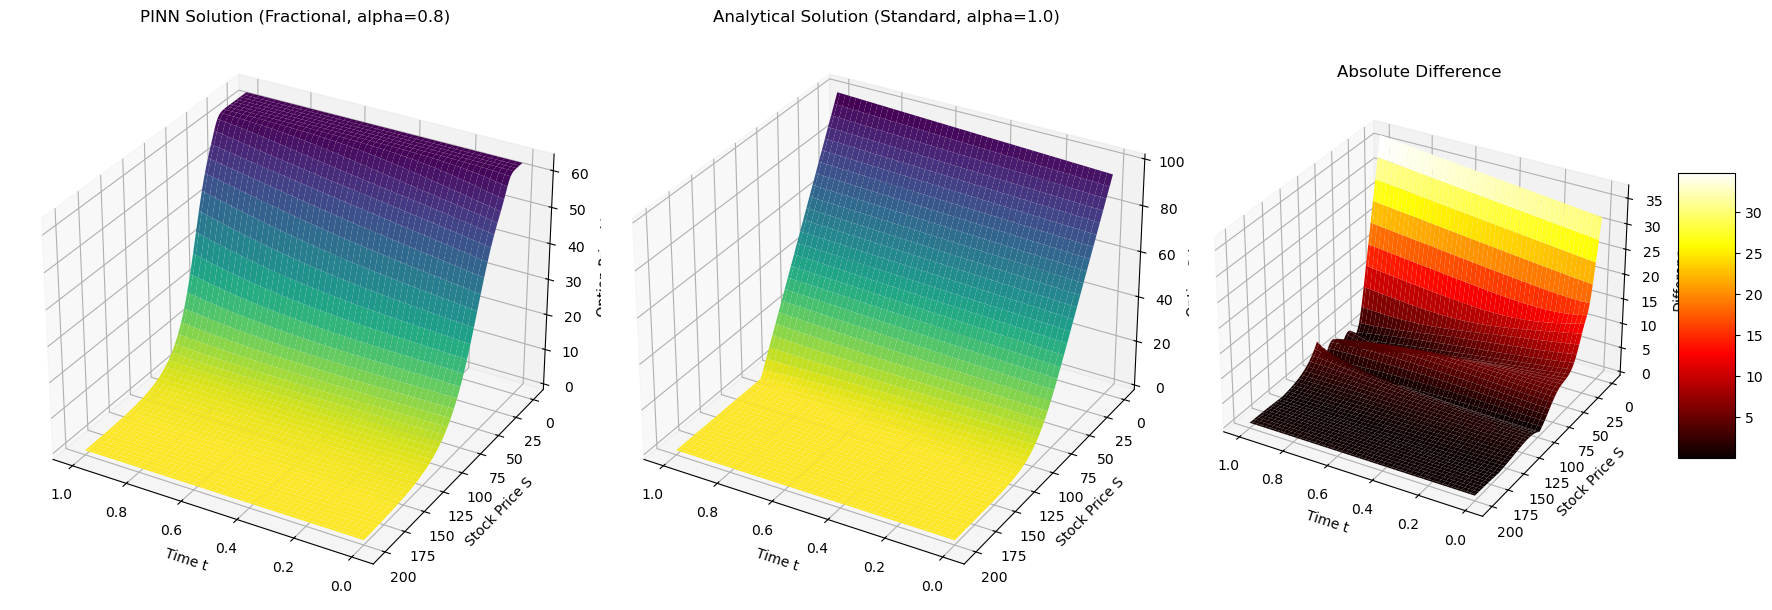

In [11]:
from scipy.stats import norm
def black_scholes_analytical_put(S, t, K, r, sigma, T):
    """Analytical solution for standard European put option."""
    if t == T:
        return np.maximum(K - S, 0)
    # Add a small epsilon to prevent division by zero at t=T
    tau = T - t
    if tau <= 1e-8:
      return np.maximum(K - S, 0)
      
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    put_price = (K * np.exp(-r * tau) * norm.cdf(-d2) - S * norm.cdf(-d1))
    return put_price

# Create a grid for plotting
S_plot = np.linspace(S_min + 1e-5, S_max, 100) # Avoid S=0 for d1/d2 calculation
t_plot = np.linspace(t_min, t_max, 100)
S_grid, t_grid = np.meshgrid(S_plot, t_plot)
grid_points = np.stack([t_grid.flatten(), S_grid.flatten()], axis=1)

# Predict using the trained PINN
V_pred = pinn_model.predict(grid_points).reshape(S_grid.shape)

# Calculate analytical solution for the standard (non-fractional) case
V_analytical = np.zeros_like(S_grid)
for i in range(len(t_plot)):
    for j in range(len(S_plot)):
        V_analytical[i, j] = black_scholes_analytical_put(S_grid[i, j], t_grid[i, j], K, r, sigma, T)

# Plotting
fig = plt.figure(figsize=(18, 6))

# PINN Solution (Fractional)
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
ax1.plot_surface(t_grid, S_grid, V_pred, cmap='viridis_r')
ax1.set_title(f'PINN Solution (Fractional, alpha={alpha})')
ax1.set_xlabel('Time t')
ax1.set_ylabel('Stock Price S')
ax1.set_zlabel('Option Price V')
ax1.view_init(30, 120)

# Analytical Solution (Standard)
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
ax2.plot_surface(t_grid, S_grid, V_analytical, cmap='viridis_r')
ax2.set_title('Analytical Solution (Standard, alpha=1.0)')
ax2.set_xlabel('Time t')
ax2.set_ylabel('Stock Price S')
ax2.set_zlabel('Option Price V')
ax2.view_init(30, 120)

# Difference Plot
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
difference = np.abs(V_pred - V_analytical)
surf = ax3.plot_surface(t_grid, S_grid, difference, cmap='hot')
ax3.set_title('Absolute Difference')
ax3.set_xlabel('Time t')
ax3.set_ylabel('Stock Price S')
ax3.set_zlabel('Difference')
ax3.view_init(30, 120)
fig.colorbar(surf, shrink=0.5, aspect=5)

plt.tight_layout()
plt.show()
